# Hotel Booking Cancellation Analysis
## Project Overview

This project analyzes hotel booking data to understand the characteristics associated with booking cancellations.

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#load the data
df = pd.read_csv('C:/Users/USER/OneDrive/Documents/Python For Data Analytics and Data Apps/Hotel Booking Analysis/hotel_bookings.csv')

In [3]:
# preview the data'
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
# dataset shape
df.shape

(119390, 32)

The dataset has 119390 rows and 32 columns

In [5]:
# dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [6]:
# check for missing values
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [7]:
# check duplicates
df.duplicated().sum()

np.int64(31994)

## Data Cleaning

In [8]:
# Fill Agent and Company 0(0 meaning booked directly)
df['agent'] = df['agent'].fillna(0)
df['company'] = df['company'].fillna(0)

In [9]:
# Fill Children 0
df['children'] = df['children'].fillna(0)

In [10]:
# Changing Children Column from float to int
df['children'] = df['children'].astype(int)

In [11]:
# drop the rest of the missing values
df = df.dropna()

In [12]:
# drop duplicates
df = df.drop_duplicates()

## Validation

In [13]:
# recheck for missing values
df.isna().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                         

In [14]:
# recheck for duplicates
df.duplicated().sum()

np.int64(0)

In [15]:
# recheck the dataset shape
df.shape

(86944, 32)

## Feature Engineering

In [16]:
# calculate total nights
df['total_nights'] = df['stays_in_week_nights'] + df['stays_in_weekend_nights']

In [17]:
# calculate total guests
df['total_guests'] = df['adults'] + df['children'] + df['babies']

In [18]:
# Check is_family (True if there are children or babies, False otherwise)
df['is_family'] = (df['babies']>0) +(df['children']>0)

In [19]:
# create 'season' based on the arrival date month
month_to_season = {
    'December': 'Winter', 'January': 'Winter', 'February': 'Winter', 'March': 'Spring',
    'April': 'Spring', 'May': 'Spring', 'June': 'Summer', 'July': 'Summer', 'August': 'Summer',
    'September': 'Fall', 'October': 'Fall', 'November': 'Fall'
}

df['season'] = df['arrival_date_month'].map(month_to_season)

In [20]:
# Preview the data
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_nights,total_guests,is_family,season
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,0,2,False,Summer
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,0,2,False,Summer
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,1,1,False,Summer
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,1,1,False,Summer
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,2015-07-03,2,2,False,Summer


In [29]:
df.to_csv('cleaned_hotel_bookings.csv', index=False)

## Exploratory Data Analysis(EDA)

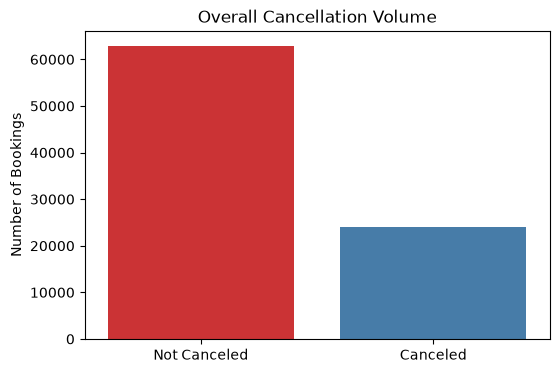

Overall Cancellation Rate: 27.6%


In [22]:
# What is the overall booking cancellation rate?
plt.figure(figsize=(6, 4))
# mapping 0 and 1 to readable labels
df['is_canceled_label'] = df['is_canceled'].map({0: 'Not Canceled', 1: 'Canceled'})

sns.countplot(data=df, x='is_canceled_label', hue='is_canceled_label', palette='Set1', legend=False)

plt.title('Overall Cancellation Volume')
plt.ylabel('Number of Bookings')
plt.xlabel('')
plt.savefig('cancellation.png')
plt.show()

# calculate the exact cancelation percentage
cancel_pct = df['is_canceled'].value_counts(normalize=True) * 100
print(f'Overall Cancellation Rate: {cancel_pct[1]:.1f}%')

The cancelation rate is 27.6% this means that 1 in 3 bokings is canceled.Thus the hotels cannot rely on the initial booking numbers for staffing or food ordering. Management must utilize an overbooking strategy to ensure the hotel is full on any given night.

C:\Users\USER\AppData\Local\Temp\ipykernel_3828\1071986999.py:9: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig('hoteltype.png')


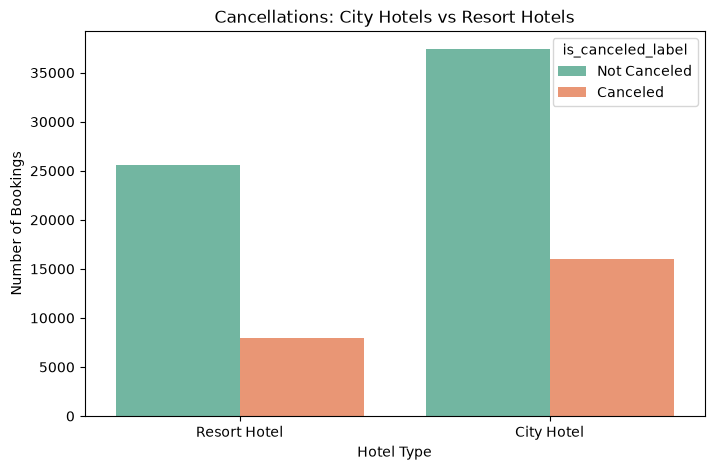

hotel         is_canceled
City Hotel    0              69.965557
              1              30.034443
Resort Hotel  0              76.296164
              1              23.703836
Name: proportion, dtype: float64

In [23]:
# Hotel Type Comparison
# Does the hotel type affect the likelihood of cancelations? We will compare City hotels 
# vs Resort Hotels to see if their customer bases behave differently?
plt.figure(figsize=(8,5))
sns.countplot(x='hotel', hue='is_canceled_label', data=df, palette='Set2')
plt.title('Cancellations: City Hotels vs Resort Hotels')
plt.ylabel('Number of Bookings')
plt.xlabel('Hotel Type')
plt.savefig('hoteltype.png')
plt.show()

# Calculate rates per hotel type
df.groupby('hotel')['is_canceled'].value_counts(normalize=True) * 100

City hotels see significantly higher booking volumes and a much higher cancellation rate than Resort Hotels. City trips are often short, impulsive or tied to business meetings that get moved. Resort trips are usually planned (often involve flights) making guests less likely to cancel.

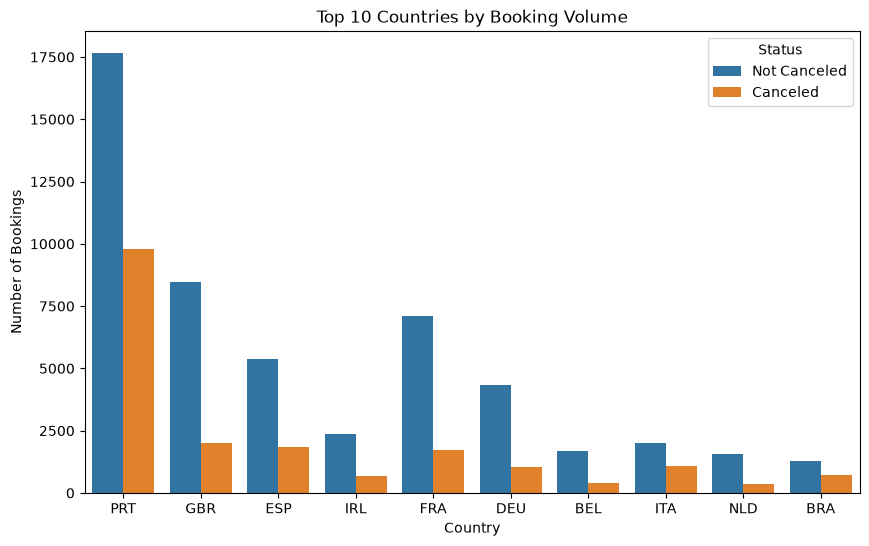

In [24]:
# Understanding the geographical origin of our customers how does it affect the cancellations?
plt.figure(figsize=(10,6))
# top 10 countries by volume
top_10_countries = df['country'].value_counts().head(10).index

sns.countplot(x='country', hue='is_canceled_label', data=df[ df['country'].isin(top_10_countries) ])
plt.title('Top 10 Countries by Booking Volume')
plt.ylabel('Number of Bookings')
plt.xlabel('Country')
plt.legend(title='Status')
plt.savefig('countries.png')
plt.show()

PRT(Portugal) generated the highest booking volume, but it also has a staggering cancellation rate. Because the hotels in this dataset are from portugal, these are local residents. Locals often book multiple hotels as 'backups' for weekend getaways because they don't have to commit to flights.

International guest rarely cancel because their bookings are locked in by airline tickets.

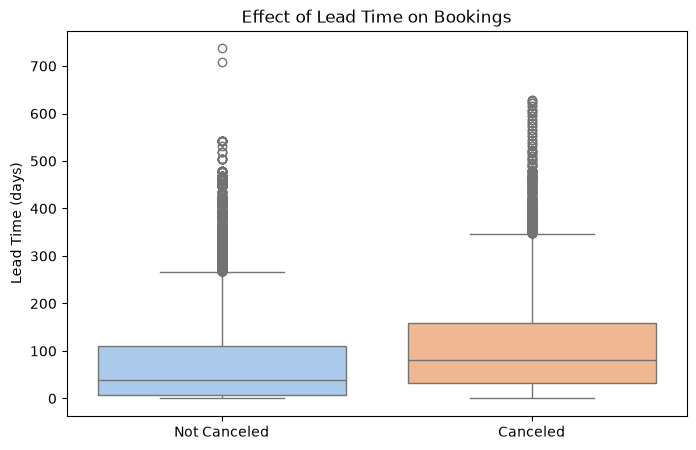

In [25]:
# Lead Time Analysis - Leadtime is the number of days between when the guest books 
# and when they arrive
# Does booking advance make the guest likely to cancel?
plt.figure(figsize=(8,5))
sns.boxplot(x='is_canceled_label', y='lead_time', data = df, hue='is_canceled_label', 
            palette='pastel', legend=False)

plt.title('Effect of Lead Time on Bookings')
plt.ylabel('Lead Time (days)')
plt.xlabel('')
plt.savefig('leadtime.png')
plt.show()

The boxplot shows that the median lead time for cancelled bookings is much higher. Simply put: the earlier someone books the more time they have to change their mind.

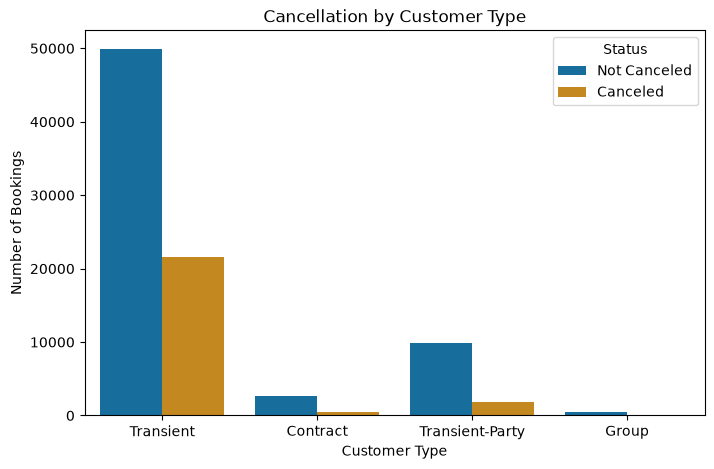

In [26]:
# Customer Type Analysis
# Are solo/transient travellers more volatile than large groups or corporate contracts?
plt.figure(figsize=(8,5))
sns.countplot(x='customer_type', hue='is_canceled_label', data = df, palette='colorblind')

plt.title('Cancellation by Customer Type')
plt.ylabel('Number of Bookings')
plt.xlabel('Customer Type')
plt.legend(title='Status')
plt.savefig('customertype.png')
plt.show()

'Transient' travellers(Independent traveller not part of a group) account for the vast majority of both bookings and cancellations. Conversely, 'Groups' and 'Contract' bookings are much more stable.
Recommendation:
The sales team should prioritize securing more B2B contracts and groups events to build stable, guaranteed revenue base that protects against volatility of individual travellers

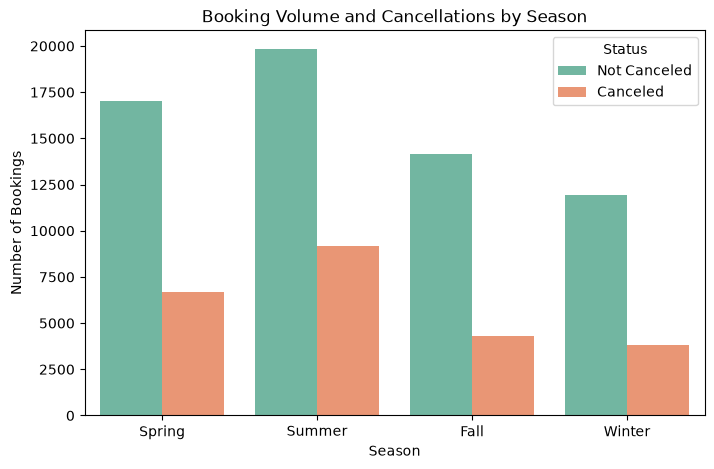

season  is_canceled
Fall    0              76.62
Winter  0              75.74
Spring  0              71.80
Summer  0              68.40
        1              31.60
Spring  1              28.20
Winter  1              24.26
Fall    1              23.38
Name: proportion, dtype: float64

In [27]:
# Seasonal Cancellation Analysis
plt.figure(figsize=(8,5))

# Logical flow of seasons
season_order = ['Spring', 'Summer', 'Fall', 'Winter']

sns.countplot(x='season', hue='is_canceled_label', data=df, order=season_order, palette='Set2')

plt.title('Booking Volume and Cancellations by Season')
plt.ylabel('Number of Bookings')
plt.xlabel('Season')
plt.legend(title='Status')
plt.savefig('seasonal.png')
plt.show()

# Calculate the cancellation rate per season
season_cancel_rate = df.groupby('season')['is_canceled'].value_counts(normalize=True) * 100
season_cancel_rate.round(2).sort_values(ascending=False)

Summer shows the highest total volume of bookings and the highest absolute number of cancellations.

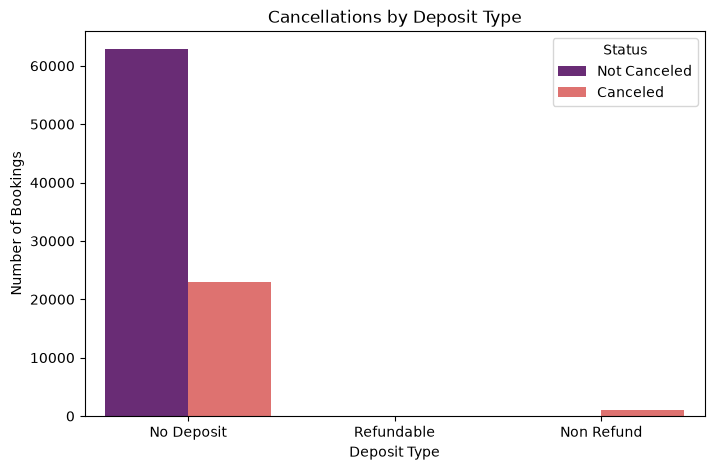

In [28]:
# impact of deposit type on cancellations
plt.figure(figsize=(8,5))
sns.countplot(x='deposit_type', hue='is_canceled_label', data=df, palette='magma')
plt.title('Cancellations by Deposit Type')
plt.ylabel('Number of Bookings')
plt.xlabel('Deposit Type')
plt.legend(title='Status')
plt.savefig('deposittype.png')
plt.show()

Majority of the bookings require no deposit. Our recommendation make the deposit compulsory and non refundable.